In this notebook, we will make some plots trying to show the different physical nature of ELG galaxies relative to BGS-B etc.


Notes: 
[OII] is typically strong in ELG
Ting-Wen Lan (10 mins) - The Diversity of ELG [OII] Line Profiles and its links to Star-formation and Morphology

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import pickle
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}


%load_ext autoreload
%autoreload 2


In [2]:
from elg_explore import (
    load_catalog,
    load_spectra,
    select_sample,
    get_sample_spectra_with_linenorm,
    bootstrap_stack,
    measure_all_lines_boxcar,
    compute_line_ratios_bootstrap,
    write_stacked_spectra,
)

In [3]:
# get_sample_spectra_with_halpha, normalize_by_halpha_catalog, bootstrap_stack, bootstrap_stack_fast_capped

In [4]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [5]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [6]:
from mass_and_photo_corrections import DWARF_CATALOG_SPEC_HDU 

In [7]:
# from elg_explore import deredshift_for_stacking

In [8]:
# deredshift_for_stacking()

In [9]:
print("[1] Loading catalog...")
tot_cat = load_catalog()
print(f"    Total galaxies after quality cuts: {len(tot_cat)}")
 

[1] Loading catalog...
Total catalog size = 461488
Cleaned catalog size = 422085
    Total galaxies after quality cuts: 422085


In [10]:
print("\n[2] Loading de-redshifted spectra...")
spectra_data = load_spectra()
print(f"    Total spectra loaded: {len(spectra_data['targetid'])}")
 


[2] Loading de-redshifted spectra...
Reading file = /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_y1_dwarf_combine_deredshift_hires.h5
    Total spectra loaded: 465872


In [11]:
wave = spectra_data["wave_rest"]
print(f"    Rest-frame wavelength range: {wave.min():.1f} - {wave.max():.1f} A")
print(f"    Wavelength grid spacing (first few):  {np.diff(wave)[:5]}")
 


    Rest-frame wavelength range: 3600.0 - 9824.0 A
    Wavelength grid spacing (first few):  [0.8000488 0.8000488 0.7998047 0.8000488 0.8000488]


In [11]:
# %% ==========================================================================
# 3. Analysis configuration
# =============================================================================
 
# ----- Emission-line boxcar windows (rest-frame, Angstroms) -----
# Format: (lambda_lo, lambda_hi, continuum_sideband_width). These windows are
# tuned for the de-redshifted stacked spectra and are the same ones used in
# the original exploration notebooks.
shorten    = -1     # global tweak to widen/narrow the Halpha window
cont_width = 10     # used for the NII_6583 sideband
LINE_WINDOWS = {
    "Halpha":    (6558.0 - shorten, 6571.0 + shorten, 5),
    "NII_6548":  (6545.0 + 1,       6555.0 - 1,       5),
    "NII_6583":  (6578.0 + 2,       6592.0 - 2,       cont_width),
    "Hbeta":     (4848.0 + 10,      4878.0 - 10,      3),
    "OIII_4959": (4945.0 + 10,      4975.0 - 10,      5),
    "OIII_5007": (4990.0 + 10,      5025.0 - 10,      5),
    "OII":       (3710.0 + 12,      3750.0 - 14,      5),
    "SII":       (6700.0 + 12,      6755.0 - 16,      5),
}
 
# ----- Stellar-mass binning (dex of log M*/Msun) -----
# We stack ELG and non-ELG dwarfs separately in each bin and require a
# minimum number of galaxies per bin (STACK_NLIM).
mstar_bins   = np.arange(6.0, 9.5, 0.25)
mstar_cens   = 0.5 * (mstar_bins[:-1] + mstar_bins[1:])
n_mstar_bins = len(mstar_bins) - 1
 
# Global redshift range for the mass-binned stacks (effectively "no" cut --
# we bin only in stellar mass, not redshift, as per the analysis plan).
Z_MIN_GLOBAL = 0.0
Z_MAX_GLOBAL = 0.5
 
# Minimum number of galaxies per bin required to perform a stack
STACK_NLIM = 50
 
# Output directory for the stacks (FITS + pkl)
STACK_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"
os.makedirs(STACK_PATH, exist_ok=True)
 
# Re-do stacks even if cached on disk?
OVERWRITE_STACKS = True
 
# Number of bootstrap realizations to write to the FITS file for FastSpecFit
N_BOOT_SAVE = 50
 
print(f"Stellar-mass bin edges (log M*/Msun): {mstar_bins}")
print(f"Number of mass bins: {n_mstar_bins}")
print(f"Stack output directory: {STACK_PATH}")
 

Stellar-mass bin edges (log M*/Msun): [6.   6.25 6.5  6.75 7.   7.25 7.5  7.75 8.   8.25 8.5  8.75 9.   9.25]
Number of mass bins: 13
Stack output directory: /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/


In [13]:
# %% --- Trim spectra wavelength grid -----------------------------------------
# Trim to lambda < 6800 A. Beyond ~6800 A there is essentially no information
# of interest for our line diagnostics (Halpha + neighbours are already inside
# this window) and the de-redshifted ivar there is very noisy for the lowest-z
# galaxies. This also speeds up the stacking + FastSpecFit downstream.
wave_mask = spectra_data["wave_rest"] < 6800
spectra_data["wave_rest"] = spectra_data["wave_rest"][wave_mask]
spectra_data["flux"]      = spectra_data["flux"][:, wave_mask]
spectra_data["flux_ivar"] = spectra_data["flux_ivar"][:, wave_mask]
 
wave = spectra_data["wave_rest"]
print(f"After trim, wavelength range: {wave.min():.1f} - {wave.max():.1f} A "
      f"({len(wave)} pixels)")
print(f"Spectra array shape: {spectra_data['flux'].shape}")
 


After trim, wavelength range: 3600.0 - 6799.2 A (4000 pixels)
Spectra array shape: (465872, 4000)


In [14]:
wave.shape

(4000,)

In [15]:
spectra_data["flux"].shape

(465872, 4000)

In [16]:
# %% ==========================================================================
# 4. Stacked analysis in stellar-mass bins
# =============================================================================
#
# For each stellar-mass bin we select the ELG and non-ELG dwarfs, look up
# their de-redshifted spectra by TARGETID, normalize each spectrum by its
# catalog Halpha flux, and bootstrap-stack. Each bin yields:
#
#   - a mean stacked spectrum
#   - a bootstrap error spectrum (std across realizations)
#   - all_stacks: a stack of n_bootstrap mean-realizations (used downstream
#     for propagating uncertainty into line ratios)
#
# Stacks are cached as pickle files; set OVERWRITE_STACKS = True above to
# recompute.
 
# Containers to hold the in-memory stacked spectra and line-ratio bootstrap
# results, keyed by the bin index i (running over mstar_bins[:-1]).
stack_spec_elg_mstar_dict    = {}
stack_spec_noelg_mstar_dict  = {}
line_ratios_elg_mstar_dict   = {}
line_ratios_noelg_mstar_dict = {}
 
for i in range(n_mstar_bins):
    mstar_min_i = mstar_bins[i]
    mstar_max_i = mstar_bins[i + 1]
    print(f"\n=== log M* in [{mstar_min_i:.2f}, {mstar_max_i:.2f}] ===")
 
    # ----- Select ELG / non-ELG sub-samples in this mass bin ---------------
    elg_sub_cat_i = select_sample(
        tot_cat, "ELG",
        z_min=Z_MIN_GLOBAL, z_max=Z_MAX_GLOBAL,
        logmstar_min=mstar_min_i, logmstar_max=mstar_max_i,
    )
    noelg_sub_cat_i = select_sample(
        tot_cat, "NO_ELG",
        z_min=Z_MIN_GLOBAL, z_max=Z_MAX_GLOBAL,
        logmstar_min=mstar_min_i, logmstar_max=mstar_max_i,
    )
 
    # ===================== ELG =====================
    if len(elg_sub_cat_i) > STACK_NLIM:
        stack_file_elg = os.path.join(
            STACK_PATH,
            f"stacks_spec_elg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl",
        )
 
        if os.path.exists(stack_file_elg) and not OVERWRITE_STACKS:
            print(f"  Loading cached ELG stack: {os.path.basename(stack_file_elg)}")
            with open(stack_file_elg, "rb") as f:
                saved = pickle.load(f)
            stack_spec_elg = saved["stack_spec"]
            stack_err_elg  = saved["stack_err"]
            all_stacks_elg = saved["all_stacks"]
        else:
            print(f"  Computing ELG stack (N = {len(elg_sub_cat_i)})")
 
            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = (
                get_sample_spectra_with_linenorm(
                    elg_sub_cat_i, spectra_data, line_norm="HALPHA"
                )
            )
 
            # Normalize each spectrum by its catalog Halpha flux, then bootstrap-stack
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack(
                fluxes=flux_elg_i,
                ivars=ivar_elg_i,
                wave=wave,
                norm_method="catalog",
                catalog_line_fluxes=haf_elg_i,
            )
 
            with open(stack_file_elg, "wb") as f:
                pickle.dump({
                    "stack_spec":  stack_spec_elg,
                    "stack_err":   stack_err_elg,
                    "all_stacks":  all_stacks_elg,
                    "mstar_min":   mstar_min_i,
                    "mstar_max":   mstar_max_i,
                    "z_min":       Z_MIN_GLOBAL,
                    "z_max":       Z_MAX_GLOBAL,
                    "n_galaxies":  len(elg_sub_cat_i),
                }, f)
            print(f"  Saved {stack_file_elg}")
 
        # Line ratios via bootstrap (captures covariances between lines)
        line_ratios_elg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        print(f"  Skipping ELG (N = {len(elg_sub_cat_i)} < {STACK_NLIM})")
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_mstar_dict[i] = None
 
    # ===================== non-ELG =====================
    if len(noelg_sub_cat_i) > STACK_NLIM:
        stack_file_noelg = os.path.join(
            STACK_PATH,
            f"stacks_spec_noelg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl",
        )
 
        if os.path.exists(stack_file_noelg) and not OVERWRITE_STACKS:
            print(f"  Loading cached non-ELG stack: {os.path.basename(stack_file_noelg)}")
            with open(stack_file_noelg, "rb") as f:
                saved = pickle.load(f)
            stack_spec_noelg = saved["stack_spec"]
            stack_err_noelg  = saved["stack_err"]
            all_stacks_noelg = saved["all_stacks"]
        else:
            print(f"  Computing non-ELG stack (N = {len(noelg_sub_cat_i)})")
 
            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = (
                get_sample_spectra_with_linenorm(
                    noelg_sub_cat_i, spectra_data, line_norm="HALPHA"
                )
            )
 
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack(
                fluxes=flux_noelg_i,
                ivars=ivar_noelg_i,
                wave=wave,
                norm_method="catalog",
                catalog_line_fluxes=haf_noelg_i,
            )
 
            with open(stack_file_noelg, "wb") as f:
                pickle.dump({
                    "stack_spec":  stack_spec_noelg,
                    "stack_err":   stack_err_noelg,
                    "all_stacks":  all_stacks_noelg,
                    "mstar_min":   mstar_min_i,
                    "mstar_max":   mstar_max_i,
                    "z_min":       Z_MIN_GLOBAL,
                    "z_max":       Z_MAX_GLOBAL,
                    "n_galaxies":  len(noelg_sub_cat_i),
                }, f)
            print(f"  Saved {stack_file_noelg}")
 
        line_ratios_noelg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        print(f"  Skipping non-ELG (N = {len(noelg_sub_cat_i)} < {STACK_NLIM})")
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_mstar_dict[i] = None
 
    stack_spec_elg_mstar_dict[i]   = stack_spec_elg
    stack_spec_noelg_mstar_dict[i] = stack_spec_noelg
 


=== log M* in [6.00, 6.25] ===
Total number selected = 18
Total number selected = 12
  Skipping ELG (N = 18 < 50)
  Skipping non-ELG (N = 12 < 50)

=== log M* in [6.25, 6.50] ===
Total number selected = 65
Total number selected = 38
  Computing ELG stack (N = 65)
NDRAW = 5000
    Catalog normalization: 65/65 spectra with valid line flux
  Saved /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_6.25_6.50.pkl
  Skipping non-ELG (N = 38 < 50)

=== log M* in [6.50, 6.75] ===
Total number selected = 204
Total number selected = 96
  Computing ELG stack (N = 204)
NDRAW = 5000
    Catalog normalization: 204/204 spectra with valid line flux
  Saved /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks_spec_elg_mstar_6.50_6.75.pkl
  Computing non-ELG stack (N = 96)
NDRAW = 5000
    Catalog normalization: 94/94 spectra with valid line flux
  Saved /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stacks

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


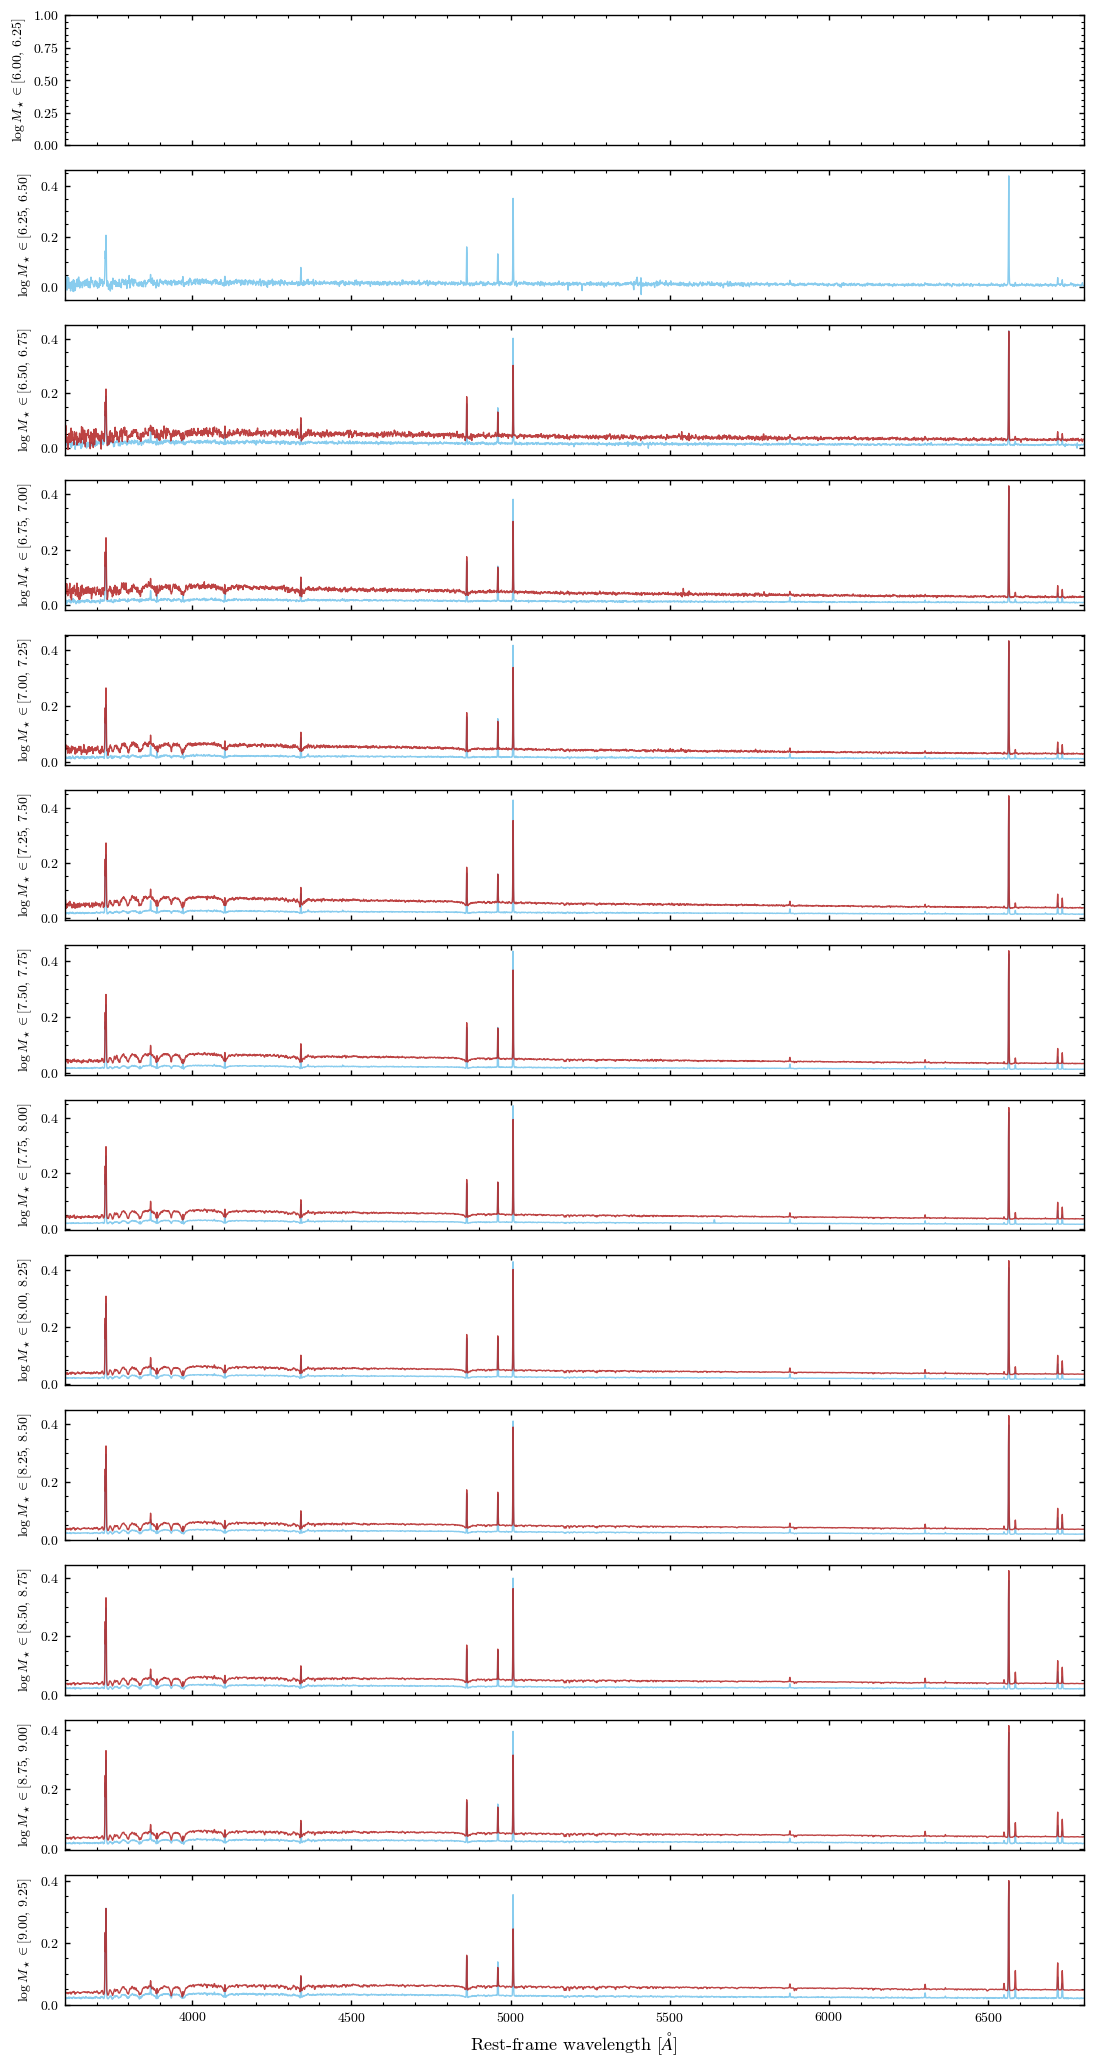

In [17]:
# %% --- Quick-look at the stacks ---------------------------------------------
# Show the ELG and non-ELG stacks side-by-side in each mass bin to verify
# that the stacking succeeded and that the major emission lines are present.
 
fig, axes = plt.subplots(n_mstar_bins, 1,
                         figsize=(11, 1.6 * n_mstar_bins),
                         sharex=True)
if n_mstar_bins == 1:
    axes = [axes]
 
for i, ax in enumerate(axes):
    ms_min_i, ms_max_i = mstar_bins[i], mstar_bins[i + 1]
 
    if not np.all(np.isnan(stack_spec_elg_mstar_dict[i])):
        ax.plot(wave, stack_spec_elg_mstar_dict[i],
                color=sample_colors["ELG"], lw=1.0, label="ELG")
    if not np.all(np.isnan(stack_spec_noelg_mstar_dict[i])):
        ax.plot(wave, stack_spec_noelg_mstar_dict[i],
                color="firebrick", lw=1.0, alpha=0.85,
                label="non-ELG")
 
    ax.set_xlim(3600, 6800)
    ax.set_ylabel(rf"$\log M_\star \in $[{ms_min_i:.2f}, {ms_max_i:.2f}]",
                  fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=10)
 
axes[-1].set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# %% ==========================================================================
# 5. Write stacks to FastSpecFit-compatible FITS files
# =============================================================================
#
# For each mass bin we write a single FITS file containing:
#
#   row 0:               the MEAN bootstrap stack
#   rows 1..N_BOOT_SAVE: a random subset of the bootstrap realizations
#
# Running stackfit on the file then gives us a FastSpecFit measurement for
# the mean spectrum PLUS N_BOOT_SAVE realizations from which we can build
# asymmetric error bars on the derived line ratios (Section 7).
 
# Trim wavelength to lambda < 6800 A for the FITS files (consistent with the
# spectra we used to build the stacks).
wave_keep_mask = wave < 6800
wave_for_fits  = wave[wave_keep_mask]
 
for sample_key, samp_dict, label in [
    ("elg",   stack_spec_elg_mstar_dict,   "ELG"),
    ("noelg", stack_spec_noelg_mstar_dict, "non-ELG"),
]:
    # Indices of bins that actually have a valid stack
    valid_indices = [
        i for i in samp_dict
        if not np.all(np.isnan(samp_dict[i]))
    ]
    if not valid_indices:
        print(f"  No valid {label} bins to write.")
        continue
 
    print(f"\nWriting {label} FITS files for {len(valid_indices)} mass bins...")
 
    for i in valid_indices:
        ms_min_i, ms_max_i = mstar_bins[i], mstar_bins[i + 1]
        pkl = os.path.join(
            STACK_PATH,
            f"stacks_spec_{sample_key}_mstar_{ms_min_i:.2f}_{ms_max_i:.2f}.pkl",
        )
        with open(pkl, "rb") as f:
            saved = pickle.load(f)
 
        flux_mean  = saved["stack_spec"]
        err_mean   = saved["stack_err"]
        all_stacks = saved["all_stacks"]   # shape (n_bootstrap, n_wave)
 
        # Convert error -> ivar; rows where err <= 0 or non-finite get ivar=0
        ivar_mean = np.where(err_mean > 0, 1.0 / err_mean**2, 0.0)
 
        # Pick a deterministic random subset of bootstrap realizations to save
        rng = np.random.default_rng(42)
        n_boot_avail = len(all_stacks)
        n_boot_keep  = min(N_BOOT_SAVE, n_boot_avail)
        boot_idx     = rng.choice(n_boot_avail, size=n_boot_keep, replace=False)
        boot_stacks  = all_stacks[boot_idx]
 
        # Row 0 = mean, rows 1..N = bootstrap realizations
        n_rows   = 1 + n_boot_keep
        all_flux = np.zeros((n_rows, len(wave)))
        all_ivar = np.zeros((n_rows, len(wave)))
 
        all_flux[0] = np.where(np.isfinite(flux_mean), flux_mean, 0.0)
        all_ivar[0] = np.where(np.isfinite(ivar_mean) & (all_flux[0] != 0),
                               ivar_mean, 0.0)
        for k, boot_flux_k in enumerate(boot_stacks, start=1):
            all_flux[k] = np.where(np.isfinite(boot_flux_k), boot_flux_k, 0.0)
            # Bootstrap realizations share the same noise estimate as the mean
            all_ivar[k] = all_ivar[0]
 
        out_fits = os.path.join(
            STACK_PATH,
            f"stack_mstar_{sample_key}_{ms_min_i:.2f}_{ms_max_i:.2f}.fits",
        )
        write_stacked_spectra(
            outfile=out_fits,
            wave=wave_for_fits,
            flux=all_flux[:, wave_keep_mask],
            ivar=all_ivar[:, wave_keep_mask],
            stackids=np.arange(n_rows),
            stack_redshift=np.zeros(n_rows),
            table_column_dict={
                "IS_MEAN": np.array([1] + [0] * n_boot_keep),
                "NOBJ":    np.full(n_rows, saved["n_galaxies"]),
            },
            table_format_dict={
                "IS_MEAN": "K",
                "NOBJ":    "K",
            },
        )
        print(f"  log M*=[{ms_min_i:.2f}, {ms_max_i:.2f}]: "
              f"1 mean + {n_boot_keep} bootstraps -> {os.path.basename(out_fits)}")
 


Writing ELG FITS files for 12 mass bins...
Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_6.25_6.50.fits
  log M*=[6.25, 6.50]: 1 mean + 50 bootstraps -> stack_mstar_elg_6.25_6.50.fits
Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_6.50_6.75.fits
  log M*=[6.50, 6.75]: 1 mean + 50 bootstraps -> stack_mstar_elg_6.50_6.75.fits
Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_6.75_7.00.fits
  log M*=[6.75, 7.00]: 1 mean + 50 bootstraps -> stack_mstar_elg_6.75_7.00.fits
Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_mstar_elg_7.00_7.25.fits
  log M*=[7.00, 7.25]: 1 mean + 50 bootstraps -> stack_mstar_elg_7.00_7.25.fits
Saved 51 stacked spectra to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/stack_m

In [16]:
# %% ==========================================================================
# 7. Read FastSpecFit output and derive line-ratio diagnostics
# =============================================================================
#
# For each mass bin and each sample we read the FastSpecFit output file,
# treat row 0 as the mean-stack measurement, and rows 1+ as bootstrap
# realizations from which we compute 16/50/84 percentile errors on each
# derived quantity.
#
# Quantities computed:
#
#   halpha_ew      : Halpha equivalent width [A]
#   ha_hb          : Balmer decrement Halpha/Hbeta
#   log_oiii_oii   : log10([OIII]5007+4959 / [OII]3726+3729)
#   log_oiii_hb    : log10([OIII] total / Hbeta)
#   log_sii_halpha : log10([SII] total / Halpha)
#   log_R23        : log10(([OIII] + [OII]) / Hbeta)
#
# Also: gas-phase metallicity via the Sanders+22 calibration (if available).
 
 
def compute_quantities_from_row(t):
    """Compute line-ratio / EW quantities from one row of a FastSpecFit table.
 
    Uses BOXFLUX where possible (more robust on stacks); falls back on
    Gaussian fluxes for [OII] (no BOXFLUX is provided for the doublet
    components by FastSpecFit).
    """
    ha         = t["HALPHA_BOXFLUX"]
    hb         = t["HBETA_BOXFLUX"]

    # ha         = t["HALPHA_FLUX"]
    # hb         = t["HBETA_FLUX"]
    
    ha_ew      = t["HALPHA_EW"]
    oiii_5007  = t["OIII_5007_BOXFLUX"]
    oiii_4959  = t["OIII_4959_BOXFLUX"]
    oiii_total = oiii_5007 + oiii_4959
    oii_total  = t["OII_3726_FLUX"]    + t["OII_3729_FLUX"]
    sii_total  = t["SII_6716_BOXFLUX"] + t["SII_6731_BOXFLUX"]
 
    with np.errstate(divide="ignore", invalid="ignore"):
        ha_hb = ha / hb
 
        oiii_oii     = oiii_total / oii_total
        log_oiii_oii = np.log10(oiii_oii) if oiii_oii > 0 else np.nan
 
        oiii_hb      = oiii_total / hb
        log_oiii_hb  = np.log10(oiii_hb) if oiii_hb > 0 else np.nan
 
        sii_ha       = sii_total / ha
        log_sii_ha   = np.log10(sii_ha) if sii_ha > 0 else np.nan
 
        r23          = (oiii_total + oii_total) / hb
        log_r23      = np.log10(r23) if r23 > 0 else np.nan
 
    return {
        "halpha_ew":      ha_ew,
        "ha_hb":          ha_hb,
        "log_oiii_oii":   log_oiii_oii,
        "log_oiii_hb":    log_oiii_hb,
        "log_sii_halpha": log_sii_ha,
        "log_R23":        log_r23,
    }
 
 
# Quantities we'll plot
QUANTITIES = [
    "halpha_ew", "ha_hb", "log_oiii_oii",
    "log_oiii_hb", "log_sii_halpha", "log_R23",
]
 
# Storage: for each quantity, hold mean (from row 0) and the 16/50/84
# percentile stats (from rows 1+) for both samples, indexed by mass bin.
mstar_data = {
    q: {
        "elg":          np.full(n_mstar_bins, np.nan),
        "elg_median":   np.full(n_mstar_bins, np.nan),
        "elg_err":      np.full(n_mstar_bins, np.nan),
        "elg_err_lo":   np.full(n_mstar_bins, np.nan),
        "elg_err_hi":   np.full(n_mstar_bins, np.nan),
        "noelg":        np.full(n_mstar_bins, np.nan),
        "noelg_median": np.full(n_mstar_bins, np.nan),
        "noelg_err":    np.full(n_mstar_bins, np.nan),
        "noelg_err_lo": np.full(n_mstar_bins, np.nan),
        "noelg_err_hi": np.full(n_mstar_bins, np.nan),
    }
    for q in QUANTITIES
}
 
 
def process_fastspec_file(fspec_file, sample_key, i):
    """Read FastSpecFit file and fill mstar_data[sample_key][i] entries.
 
    Parameters
    ----------
    fspec_file : str
        Path to fastspec_*.fits.
    sample_key : str
        "elg" or "noelg".
    i : int
        Mass-bin index.
    """
    if not os.path.exists(fspec_file):
        return False
    try:
        t = Table.read(fspec_file, hdu=3)
    except Exception as e:
        print(f"    Could not read {fspec_file}: {e}")
        return False
 
    # Row 0 = mean stack
    mean_vals = compute_quantities_from_row(t[0])
    for q in QUANTITIES:
        mstar_data[q][sample_key][i] = mean_vals[q]
 
    # Rows 1+ = bootstrap realizations -> percentile-based errors
    if len(t) > 1:
        boot_vals = {q: [] for q in QUANTITIES}
        for b in range(1, len(t)):
            bv = compute_quantities_from_row(t[b])
            for q in QUANTITIES:
                boot_vals[q].append(bv[q])
        for q in QUANTITIES:
            boot_arr = np.array(boot_vals[q])
            p16, p50, p84 = np.nanpercentile(boot_arr, [16, 50, 84])
            mstar_data[q][f"{sample_key}_median"][i] = p50
            mstar_data[q][f"{sample_key}_err"][i]    = 0.5 * (p84 - p16)
            mstar_data[q][f"{sample_key}_err_lo"][i] = p50 - p16
            mstar_data[q][f"{sample_key}_err_hi"][i] = p84 - p50
    return True
 
 
# Optional: metallicity via Sanders+22. Wrapped in try/except so the script
# still runs in environments where the `metallicity` module isn't importable.
try:
    from metallicity import get_metallicity_S22
    HAVE_METALLICITY = True
except ImportError:
    print("Note: metallicity module not importable; skipping S22 metallicity.")
    HAVE_METALLICITY = False
 
elg_zmet   = np.full(n_mstar_bins, np.nan)
noelg_zmet = np.full(n_mstar_bins, np.nan)
 
# --- Loop over bins and fill mstar_data --------------------------------------
for i in range(n_mstar_bins):
    ms_min_i, ms_max_i = mstar_bins[i], mstar_bins[i + 1]
 
    elg_file = os.path.join(
        STACK_PATH,
        f"fastspec_stack_mstar_elg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits",
    )
    noelg_file = os.path.join(
        STACK_PATH,
        f"fastspec_stack_mstar_noelg_{ms_min_i:.2f}_{ms_max_i:.2f}.fits",
    )
 
    process_fastspec_file(elg_file,   "elg",   i)
    process_fastspec_file(noelg_file, "noelg", i)
 
    if HAVE_METALLICITY:
        for fspec_file, arr in [(elg_file, elg_zmet), (noelg_file, noelg_zmet)]:
            if os.path.exists(fspec_file):
                try:
                    zmet_vals, _ = get_metallicity_S22(Table.read(fspec_file, hdu=3))
                    arr[i] = np.nanmedian(zmet_vals)
                except Exception:
                    pass
 

Note: metallicity module not importable; skipping S22 metallicity.


In [17]:
mag_g_rest = tot_cat["MAG_G"].data #+ tot_cat["DELTA_MAG_G_KCORR"].data
mag_r_rest = tot_cat["MAG_R"].data #+ tot_cat["DELTA_MAG_R_KCORR"].data
gr_rest = mag_g_rest - mag_r_rest

elg_mask = (tot_cat["SAMPLE"] == "ELG") & (tot_cat["MSTAR_MASKBIT"] == 0) & (tot_cat["Z"] < 0.1) & (tot_cat["MAG_TYPE"] == "TRACTOR_OG")
noelg_mask = (tot_cat["SAMPLE"] != "ELG") & (tot_cat["SAMPLE"] != "OTHER")  & (tot_cat["Z"] < 0.1)


In [18]:
from desi_lowz_funcs import plot_2d_dist, make_subplots
from catalog_paper_plots import make_cmap


/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: divide by zero encountered in true_divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: linewidths is ignored by contourf
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py

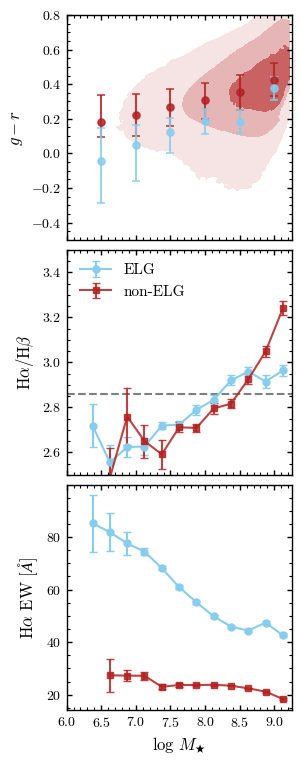

In [25]:
fig, ax = make_subplots(ncol=1, nrow=3, return_fig=True, plot_size = 2.25,
                       row_spacing=[MARGIN_LABEL-0.4, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
                       col_spacing=[MARGIN_LABEL-0.35, MARGIN_PAD])

#########

plot_2d_dist( tot_cat["LOG_MSTAR_M24"].data[noelg_mask], gr_rest[noelg_mask], 125, 125, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[2], bounds= np.array([ 6,9.25,-0.5,0.8 ]),
            cmap = make_cmap("firebrick"), color = "k", filled=True, label = "BGS Bright",cmap_alpha=1)

bin_width = 0.2
for xcen in np.arange(6,9.25,0.5):
    xdata = tot_cat["LOG_MSTAR_M24"].data[noelg_mask]
    ydata = gr_rest[noelg_mask]

    noelg_color = "firebrick" 
    
    mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
    if mask.sum() > 25:
        med = np.median(ydata[mask])
        p16 = np.percentile(ydata[mask], 16)
        p84 = np.percentile(ydata[mask], 84)

        ax[2].errorbar(xcen, med,
                     yerr=[[med - p16], [p84 - med]],
                     fmt='o', color=noelg_color, markeredgecolor=noelg_color,
                     markeredgewidth=1.2, markersize=5, alpha=0.85,
                     ecolor=noelg_color, elinewidth=1.5, capsize=3, zorder=10)

    elg_color =  sample_colors["ELG"]
    
    xdata = tot_cat["LOG_MSTAR_M24"].data[elg_mask]
    ydata = gr_rest[elg_mask]
    
    mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
    if mask.sum() > 25:
        med = np.median(ydata[mask])
        p16 = np.percentile(ydata[mask], 16)
        p84 = np.percentile(ydata[mask], 84)

        ax[2].errorbar(xcen, med,
                     yerr=[[med - p16], [p84 - med]],
                     fmt='o', color=elg_color, markeredgecolor=elg_color,
                     markeredgewidth=1.2, markersize=5, alpha=0.85,
                     ecolor=elg_color, elinewidth=1.5, capsize=3, zorder=10)

ax[2].set_ylim([-0.5,0.8])

#########

plot_config = [
    (ax[0], "halpha_ew",    r"H$\alpha$ EW [$\AA$]"),
    (ax[1], "ha_hb",        r"H$\alpha$/H$\beta$"),
]
 
for axi, qname, ylabel in plot_config:
    axi.errorbar(mstar_cens, mstar_data[qname]["elg"],
                 yerr=mstar_data[qname]["elg_err"],
                 fmt="o-", capsize=3,
                 color=sample_colors["ELG"], label="ELG")
    axi.errorbar(mstar_cens, mstar_data[qname]["noelg"],
                 yerr=mstar_data[qname]["noelg_err"],
                 fmt="s-", capsize=3, alpha=0.85,
                 color="firebrick", label="non-ELG")
    axi.set_ylabel(ylabel)
 
# Balmer-decrement Case-B reference (T = 1e4 K)
ax[1].axhline(2.86, color="k", ls="--", alpha=0.5, lw=1.5, zorder=0)

ax[1].set_ylim([2.5,3.5])

ax[0].set_xlabel(r"log $M_{\bigstar}$")

ax[2].set_ylabel(r"$g-r$")

ax[1].legend(frameon=False)

for i in range(3):
    ax[i].set_xticks([6,6.5,7, 7.5, 8, 8.5, 9])
    ax[i].set_xlim(6, 9.25)

ax[1].set_xticklabels([])
ax[2].set_xticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/elg_vs_not_elg.pdf")

plt.show()
 

In [23]:
# fig,ax = make_subplots(ncol = 1, nrow = 1, return_fig=True)

# # norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=zred_cens.max())
# norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=0.35)
# # norm = mcolors.Normalize(vmin=0.0375, vmax=0.4)

# cmap = cmr.arctic  # or viridis, coolwarm, etc.

# # scatter points colored by redshift
# sc = ax[0].scatter(gr_obs_elg, rz_obs_elg, c=zred_cens, cmap=cmap, norm=norm,
#                    edgecolors='k', linewidths=0.5, s=50, zorder=3)

# # optionally color the line segments too
# for i in range(len(gr_elg)-1):
#     ax[0].plot(gr_obs_elg[i:i+2], rz_obs_elg[i:i+2],
#                color=cmap(norm(zred_cens[i])), zorder=2)

# # inset colorbar
# cbax = ax[0].inset_axes([0.075, 0.91, 0.35, 0.02])  # wide & short for horizontal
# cbar = plt.colorbar(sc, cax=cbax, orientation='horizontal')
# cbar.set_label(r"$z$", fontsize=13, labelpad=5)  # negative pad puts label on top
# cbar.ax.tick_params(labelsize=10, bottom=True, top=False)
# cbar.ax.set_xticks([0.1,0.2,0.3])
# cbar.ax.xaxis.set_label_position('top')

# ####


# ellipse_bins = [3]

# for i in ellipse_bins:
#     w, h, angle = ellipse_obs_elg[i]
#     if np.isfinite(w):
#         ellipse = Ellipse((gr_obs_elg[i], rz_obs_elg[i]), width=w, height=h, angle=angle,
#                   facecolor='none', edgecolor=cmap(norm(zred_cens[i])), linewidth=1.5, zorder=5, ls="dotted", alpha=0.7)
#         ax[0].add_patch(ellipse)
    

# nonelg_color = "firebrick"

# plot_2d_dist(tot_cat_no_elg["g-r"], tot_cat_no_elg["r-z"], 150, 150, 
#                 cmin=1.e-4, cmax=1.0, smooth=None, clevs=[0,0.393,0.865,0.989],ax=ax[0], bounds= np.array([ -1,1,-1,1]),
#             cmap = make_cmap("firebrick"), color = nonelg_color, filled=True, cmap_alpha=1)

# start = 0.175

# ax[0].text(0.14,0.6,"ELG",color = "tab:blue", transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center",alpha=1 )

# ax[0].text(0.75,0.17,"non-ELG",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center" )

# zred_med_noelg = np.median(tot_cat_no_elg["Z"])

# ax[0].text(0.75,0.1,rf"$(z_{{\rm med}} \sim {zred_med_noelg:.3f})$",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 13,ha="center",va="center" )


# ax[0].set_xlim([0,0.8])
# ax[0].set_ylim([0,0.7])

# ax[0].set_xlabel(r"$(g-r)_{0}$",fontsize=17)
# ax[0].set_ylabel(r"$(r-z)_{0}$",fontsize=17)

# # ax[0].set_xticks([0,0.25,0.5,0.75])
# # ax[0].set_yticks([0,0.25,0.5,0.75])

# ###plot the ELG color selection:

# gr_elg_box = [-0.5039115756670784, 0.17415113938843074, 0.5343050055184053, -0.5072323573329873 ]
# rz_elg_box = [0.13744075829383862, 0.14691943127962093, 0.8720379146919433, 1.753554502369668 ]

# ax[0].plot(gr_elg_box, rz_elg_box,color="k",ls="dotted")

# # from matplotlib.patches import Polygon

# # # Define vertices that enclose the region above/left of the color box
# # # Go along the box boundary, then extend to the plot corners
# # shade_verts = [
# #     (gr_elg_box[0], rz_elg_box[0]),  # bottom-left of box
# #     (gr_elg_box[1], rz_elg_box[1]),  # bottom-right of box
# #     (gr_elg_box[2], rz_elg_box[2]),  # top-right of box
# #     (gr_elg_box[3], rz_elg_box[3]),  # top-left of box
# #     # now extend to plot corners (upper-left region)
# #     (ax[0].get_xlim()[0], ax[0].get_ylim()[1]),  # top-left corner
# #     (ax[0].get_xlim()[0], rz_elg_box[0]),         # back to left edge at box height
# # ]

# # shade = Polygon(shade_verts, closed=True, facecolor='dodgerblue', alpha=0.15, edgecolor='none', zorder=0)
# # ax[0].add_patch(shade)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_gr_rz_plot.pdf",bbox_inches="tight")

# plt.show()